<a href="https://colab.research.google.com/github/ramalias/crop-monitoring-research/blob/main/study_area_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import library

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch, Polygon, Rectangle
from matplotlib.lines import Line2D
from shapely.geometry import Point, shape, box
import numpy as np
import rasterio
from rasterio.features import shapes
import os
import re
from pyproj import Transformer

!pip install contextily -q
import contextily as cx

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data

In [6]:
# ── Paths per year ──
YEAR_CONFIG = {
    2023: {
        'raster_path': '/content/drive/MyDrive/00_shortcut/06_ARS/02_preprocess/Sentinel2/02_양파_연구/01_양파/06_final_preprocessing/2차/04_합천군/max_ndvi/S2_2022_2023_chogyemyeon_biweekly_maxndvi_final.tif',
        'parcel_path': '/content/drive/MyDrive/00_shortcut/06_ARS/ 01_raw_data/01_3DLab/2차전달본(0722)/2023/32652_GPKG/시군구/2023_경상남도/2023_경상남도_합천군.gpkg',
    },
    2024: {
        'raster_path': '/content/drive/MyDrive/00_shortcut/06_ARS/02_preprocess/Sentinel2/02_양파_연구/01_양파/06_final_preprocessing/2차/04_합천군/max_ndvi/S2_2023_2024_chogyemyeon_biweekly_maxndvi_final.tif',
        'parcel_path': '/content/drive/MyDrive/00_shortcut/06_ARS/ 01_raw_data/01_3DLab/2차전달본(0722)/2024/32652_GPKG/시군구/2024_경상남도/2024_경상남도_합천군.gpkg',
    },
    2025: {
        'raster_path': '/content/drive/MyDrive/00_shortcut/06_ARS/02_preprocess/Sentinel2/02_양파_연구/01_양파/06_final_preprocessing/2차/04_합천군/max_ndvi/S2_2024_2025_chogyemyeon_biweekly_maxndvi_final.tif',
        'parcel_path': '/content/drive/MyDrive/00_shortcut/06_ARS/ 01_raw_data/01_3DLab/2차전달본(0722)/2025/32652_GPKG/시군구/2025_경상남도/2025_경상남도_합천군.gpkg',
    },
}

# ── Shared settings ──
TARGET_EUPMYEON = "합천군 초계면"
ADDR_COL = "STDG_ADDR"
LABEL_COL = "CROP_NM"
MIX_COL = "MIX_CRP"
MIX_RT_COL = "MIX_RT"
NON_CROP_LABELS = ["휴경지", "제외", "비경지", "시설", "기타"]
NODATA_VALUE = -32768
SCALE_FACTOR = 1000
SEASON_MONTHS = [10, 11, 12, 1, 2, 3, 4, 5]


SPECTRAL_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
TARGET_INDICES = ["NDVI", "EVI2", "NDRE"]
ALL_TARGETS = SPECTRAL_BANDS + TARGET_INDICES
PHENOLOGY_TARGETS = TARGET_INDICES

OUTPUT_DIR = "/content/drive/MyDrive/00_shortcut/06_ARS/02_preprocess/Sentinel2/02_양파_연구/01_양파/시간적인/result"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [7]:
for year, config in YEAR_CONFIG.items():
    print(f"\n{'='*60}\nYEAR {year}\n{'='*60}")

    # ── Check files exist first ──
    raster_exists = os.path.exists(config['raster_path'])
    parcel_exists = os.path.exists(config['parcel_path'])
    print(f"Raster exists: {raster_exists}  |  Parcel exists: {parcel_exists}")

    if not raster_exists:
        print(f"  RASTER NOT FOUND: {config['raster_path']}")
    if not parcel_exists:
        print(f"  PARCEL NOT FOUND: {config['parcel_path']}")
        continue  # skip further checks if file missing

    # ── Raster check ──
    if raster_exists:
        with rasterio.open(config['raster_path']) as src:
            print(f"\n--- Raster ---")
            print("Bands:", src.count)
            print("Size:", src.width, "x", src.height)
            print("CRS:", src.crs)
            print("Bounds:", src.bounds)
            print("Nodata:", src.nodata)
            print("First 3 band names:", src.descriptions[:3])
            print("Last 3 band names:", src.descriptions[-3:])

    # ── Parcel check ──
    gdf = gpd.read_file(config['parcel_path'])
    print(f"\n--- Parcels ---")
    print("Shape:", gdf.shape)
    print("CRS:", gdf.crs)
    print("Columns:", gdf.columns.tolist())

    # Check expected columns actually exist (since this is a new source: 3DLab)
    if ADDR_COL not in gdf.columns:
        print(f"  ADDR_COL '{ADDR_COL}' NOT in columns!")
    if LABEL_COL not in gdf.columns:
        print(f"  LABEL_COL '{LABEL_COL}' NOT in columns!")

    if ADDR_COL in gdf.columns:
        matching = gdf[gdf[ADDR_COL].str.contains(TARGET_EUPMYEON, na=False)]
        print(f"Parcels matching '{TARGET_EUPMYEON}': {len(matching)} out of {len(gdf)} total")

        if LABEL_COL in gdf.columns and len(matching) > 0:
            print(f"\nCrop label distribution in {TARGET_EUPMYEON}:")
            print(matching[LABEL_COL].value_counts().head(15))


YEAR 2023
Raster exists: True  |  Parcel exists: True

--- Raster ---
Bands: 374
Size: 454 x 590
CRS: EPSG:32652
Bounds: BoundingBox(left=429820.0, bottom=3930590.0, right=434360.0, top=3936490.0)
Nodata: -32768.0
First 3 band names: ('2022-08-P1_B2', '2022-08-P1_B3', '2022-08-P1_B4')
Last 3 band names: ('2023-06-P2_GNDVI', '2023-06-P2_NDMI', '2023-06-P2_MSAVI2')

--- Parcels ---
Shape: (98529, 32)
CRS: EPSG:32652
Columns: ['ID', 'UID', 'CLSF_NM', 'CLSF_CD', 'STDG_CD', 'STDG_ADDR', 'PNU', 'LDCG_CD', 'SB_PNU', 'SB_LDCG_CD', 'AREA', 'CAD_CON_RA', 'SOURCE_NM', 'SOURCE_CD', 'FLIGHT_YMD', 'UPDT_YMD', 'UPDT_TP_NM', 'UPDT_TP_CD', 'CHG_RSN_NM', 'CHG_RSN_CD', 'FL_ARMT_YN', 'O_UID', 'O_CLSF_NM', 'FMAP_ID', 'PARCEL_ID', 'LAND_TYP', 'SURV_AREA', 'CROP_NM', 'PLT_RATE', 'MIX_CRP', 'MIX_RT', 'geometry']
Parcels matching '합천군 초계면': 4033 out of 98529 total

Crop label distribution in 합천군 초계면:
CROP_NM
휴경지    2174
제외      672
마늘      578
양파      286
시설       77
배추       73
기타       72
비경지      14
무     

## function

### band parsing and labelling

In [8]:
def build_target_df(raster_path, all_targets, season_months=None):
    with rasterio.open(raster_path) as src:
        descriptions = src.descriptions
    band_info = []
    for i, desc in enumerate(descriptions, start=1):
        match = re.match(r"^(\d{4}-\d{2})-P([12])_([A-Z0-9]+)$", desc)
        if match:
            year_month, period, index_name = match.groups()
            band_info.append({"band_index": i, "year_month": year_month, "period": period,
                               "index": index_name, "desc": desc})
    band_df = pd.DataFrame(band_info)
    target_df = band_df[band_df['index'].isin(all_targets)].copy()

    def period_to_date(year_month, period):
        day = "01" if period == "1" else "15"
        return pd.to_datetime(f"{year_month}-{day}")

    target_df['date'] = target_df.apply(lambda r: period_to_date(r['year_month'], r['period']), axis=1)
    if season_months is not None:
        target_df = target_df[target_df['date'].dt.month.isin(season_months)]
    target_df = target_df.sort_values(['date', 'index']).reset_index(drop=True)
    return target_df

def map_crop_label_row(row, label_col='CROP_NM', mix_col='MIX_CRP', mix_rt_col='MIX_RT'):
    crop_name = row[label_col]
    mix_crop = row.get(mix_col, None)
    mix_rt = row.get(mix_rt_col, None)

    if pd.isna(crop_name) or (isinstance(crop_name, str) and crop_name.strip() == ""):
        return None

    if crop_name in NON_CROP_LABELS:
        return None

    has_mix = (isinstance(mix_crop, str) and mix_crop.strip() != "") or \
              (pd.notna(mix_rt) and mix_rt not in [0, "0", "0%", ""])

    if crop_name == "양파":
        return None if has_mix else "양파"
    elif crop_name == "마늘":
        return None if has_mix else "마늘"
    else:
        return None if has_mix else "기타"

def build_labeled_parcels(parcel_path, addr_col, label_col, target_eupmyeon,
                            mix_col='MIX_CRP', mix_rt_col='MIX_RT'):
    gdf = gpd.read_file(parcel_path)
    gdf_filtered = gdf[gdf[addr_col].str.contains(target_eupmyeon, na=False)].copy()
    gdf_filtered['label'] = gdf_filtered.apply(
        lambda row: map_crop_label_row(row, label_col, mix_col, mix_rt_col), axis=1
    )
    gdf_filtered = gdf_filtered[gdf_filtered['label'].notna()].copy()
    return gdf_filtered

In [9]:
for year, config in YEAR_CONFIG.items():
    parcels_year = build_labeled_parcels(config['parcel_path'], ADDR_COL, LABEL_COL, TARGET_EUPMYEON, MIX_COL, MIX_RT_COL)
    print(f"{year}: {parcels_year['label'].value_counts().to_dict()}")

2023: {'마늘': 411, '양파': 255, '기타': 2}
2024: {'마늘': 548, '양파': 242}
2025: {'마늘': 430, '양파': 269, '기타': 46}


In [10]:
for year, config in YEAR_CONFIG.items():
    gdf = gpd.read_file(config['parcel_path'])
    gdf_filtered = gdf[gdf[ADDR_COL].str.contains(TARGET_EUPMYEON, na=False)].copy()
    gdf_filtered['label'] = gdf_filtered.apply(
        lambda row: map_crop_label_row(row, LABEL_COL, MIX_COL, MIX_RT_COL), axis=1
    )
    others = gdf_filtered[gdf_filtered['label'] == '기타']
    print(f"\n{year} — actual crops inside 기타:")
    print(others[LABEL_COL].value_counts())


2023 — actual crops inside 기타:
CROP_NM
배추    2
Name: count, dtype: int64

2024 — actual crops inside 기타:
Series([], Name: count, dtype: int64)

2025 — actual crops inside 기타:
CROP_NM
배추     30
대파     10
양배추     4
무       2
Name: count, dtype: int64


### Extraction

In [11]:
def extract_features_for_year(raster_path, parcel_gdf, target_df, nodata_value, scale_factor, year_label):
    target_band_indices = target_df['band_index'].tolist()
    feature_names = [f"{row['index']}_{row['date'].strftime('%m%d')}" for _, row in target_df.iterrows()]
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs
    if parcel_gdf.crs != raster_crs:
        parcel_gdf = parcel_gdf.to_crs(raster_crs)

    records = []
    with rasterio.open(raster_path) as src:
        for idx, row in tqdm(parcel_gdf.iterrows(), total=len(parcel_gdf), desc=f"Extract {year_label}"):
            try:
                out_image, _ = mask(src, [row.geometry], crop=True, indexes=target_band_indices, all_touched=True)
                out_image = out_image.astype(float)
                out_image[out_image == nodata_value] = np.nan
                out_image = out_image / scale_factor
                means = np.nanmean(out_image.reshape(out_image.shape[0], -1), axis=1)
                record = dict(zip(feature_names, means))
                record['parcel_id'] = f"{year_label}_{idx}"
                record['label'] = row['label']
                record['year'] = year_label
                records.append(record)
            except Exception as e:
                print(f"Skipping parcel {idx} ({year_label}): {e}")
    return pd.DataFrame(records)

### Phenology

In [12]:
def _loocv_spline_smoothing(day_num, values, n_candidates=15):
    var = np.var(values)
    n = len(day_num)
    if var == 0 or n < 4:
        return max(var * n * 0.1, 1e-6)
    candidates = np.geomspace(max(var * n * 0.001, 1e-8), var * n * 2, n_candidates)
    best_s, best_err = candidates[0], np.inf
    for s in candidates:
        errs = []
        for i in range(n):
            x_train = np.delete(day_num, i)
            y_train = np.delete(values, i)
            try:
                spl = UnivariateSpline(x_train, y_train, s=s)
                pred = spl(day_num[i])
                errs.append((pred - values[i]) ** 2)
            except Exception:
                errs.append(np.inf)
        mse = np.mean(errs)
        if mse < best_err:
            best_err, best_s = mse, s
    return best_s


def fit_spline(day_num, values, smoothing_factor=None):
    if smoothing_factor is None:
        smoothing_factor = _loocv_spline_smoothing(day_num, values)
    spl = UnivariateSpline(day_num, values, s=smoothing_factor)
    dense_days = np.linspace(day_num.min(), day_num.max(), 200)
    return spl, dense_days, spl(dense_days)


def extract_derivative_points(dense_days, fitted_curve, ignore_percent=0.1):
    dt = dense_days[1] - dense_days[0]
    derivative = np.gradient(fitted_curve, dt)
    num_points = len(dense_days)
    ignore_count = int(num_points * ignore_percent)
    search_start_idx = ignore_count
    search_end_idx = num_points - ignore_count
    if search_end_idx <= search_start_idx:
        search_start_idx, search_end_idx = 0, num_points

    trough_idx = search_start_idx + np.argmin(fitted_curve[search_start_idx:search_end_idx])
    pos_search_start = trough_idx
    pos_idx = pos_search_start + np.argmax(fitted_curve[pos_search_start:search_end_idx])

    if pos_idx > search_start_idx:
        sos_idx = search_start_idx + np.argmax(derivative[search_start_idx:pos_idx])
    else:
        sos_idx = search_start_idx

    if search_end_idx - 1 > pos_idx:
        eos_idx = (pos_idx + 1) + np.argmin(derivative[pos_idx + 1:search_end_idx])
    else:
        eos_idx = search_end_idx - 1

    return {"SOS_idx": sos_idx, "POS_idx": pos_idx, "EOS_idx": eos_idx,
            "SOS_day": dense_days[sos_idx], "POS_day": dense_days[pos_idx], "EOS_day": dense_days[eos_idx]}, derivative


def extract_curve_shape_features(dense_days, fitted_curve, derivative, points):
    sos_idx, pos_idx, eos_idx = points["SOS_idx"], points["POS_idx"], points["EOS_idx"]
    growth_rate = (fitted_curve[pos_idx] - fitted_curve[sos_idx]) / (dense_days[pos_idx] - dense_days[sos_idx]) if pos_idx > sos_idx else np.nan
    post_peak_decline_rate = (fitted_curve[-1] - fitted_curve[pos_idx]) / (dense_days[-1] - dense_days[pos_idx]) if len(dense_days)-1 > pos_idx else np.nan
    return {
        "Growth_Rate": growth_rate,
        "Max_Growth_Rate": derivative[sos_idx],
        "Peak_Timing_day": dense_days[pos_idx],
        "Max_Decline_Rate": derivative[eos_idx],
        "Post_Peak_Decline_Rate": post_peak_decline_rate,
        "AUC": np.trapezoid(fitted_curve, dense_days),
    }


def add_phenology_features(df, target_df, phenology_targets):
    phenology_cols = []
    for name in phenology_targets:
        date_rows = target_df[target_df['index']==name].sort_values('date')
        cols = [f"{name}_{d.strftime('%m%d')}" for d in date_rows['date']]
        cols = [c for c in cols if c in df.columns]
        if len(cols) < 4:
            continue
        day_nums = np.array([(d - date_rows['date'].min()).days for d in date_rows['date']])[:len(cols)]

        out_keys = [f"{name}_SOS_day", f"{name}_POS_day", f"{name}_EOS_day",
                    f"{name}_Growth_Rate", f"{name}_Max_Growth_Rate",
                    f"{name}_Max_Decline_Rate", f"{name}_Post_Peak_Decline_Rate", f"{name}_AUC"]
        results = {k: [] for k in out_keys}

        for _, row in df.iterrows():
            values = row[cols].values.astype(float)
            valid = ~np.isnan(values)
            if valid.sum() < 4:
                for k in results: results[k].append(np.nan)
                continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    spl, dense_days, fitted_curve = fit_spline(day_nums[valid], values[valid])
                points, derivative = extract_derivative_points(dense_days, fitted_curve)
                shape = extract_curve_shape_features(dense_days, fitted_curve, derivative, points)
                results[f"{name}_SOS_day"].append(points["SOS_day"])
                results[f"{name}_POS_day"].append(points["POS_day"])
                results[f"{name}_EOS_day"].append(points["EOS_day"])
                results[f"{name}_Growth_Rate"].append(shape["Growth_Rate"])
                results[f"{name}_Max_Growth_Rate"].append(shape["Max_Growth_Rate"])
                results[f"{name}_Max_Decline_Rate"].append(shape["Max_Decline_Rate"])
                results[f"{name}_Post_Peak_Decline_Rate"].append(shape["Post_Peak_Decline_Rate"])
                results[f"{name}_AUC"].append(shape["AUC"])
            except Exception:
                for k in results: results[k].append(np.nan)

        for k, v in results.items():
            df[k] = v
        phenology_cols += out_keys
    return df, phenology_cols

### Study Area

Raster footprint is rectangular → set BOUNDARY_PATH for the real 읍면 outline.
Zoom centre (EPSG:32652): (433026, 3934472)
Basemap skipped: name 'cx' is not defined


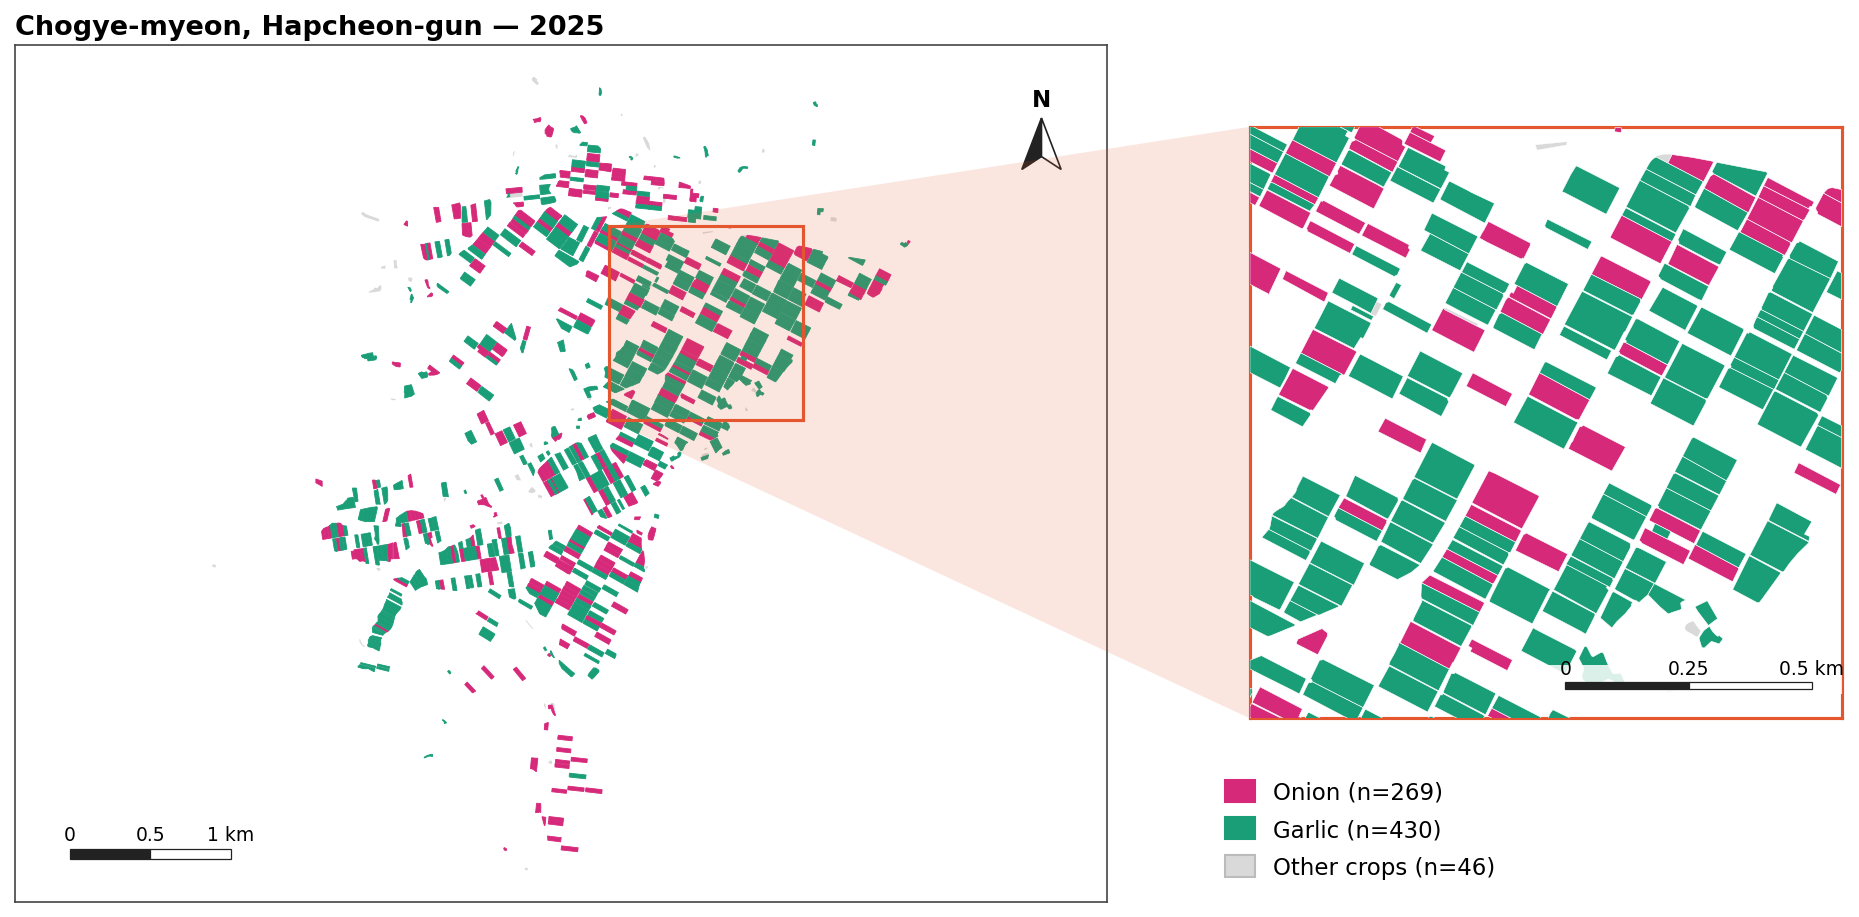

In [17]:
# ══════════════════════════════════════════════════════════════════════
# Study area: crop map + zoom inset
# Run AFTER the config cell and the cell that defines build_labeled_parcels.
# ══════════════════════════════════════════════════════════════════════
from rasterio.features import shapes
from shapely.geometry import shape, box
from scipy.spatial import ConvexHull
from matplotlib.patches import Patch, Polygon, Rectangle
from matplotlib.lines import Line2D

# ── Settings ──
MAP_CRS = "EPSG:32652"
YEAR = 2025                               # year to map
FOCUS_STYLE = {                           # main classes: label → (colour, legend text)
    "양파": ("#d6297a", "Onion"),
    "마늘": ("#1a9e77", "Garlic"),
}
OTHER_LABEL, OTHER_COLOR, OTHER_TEXT = "기타", "#d9d9d9", "Other crops"   # grey background
SHOW_OTHER = True

BOUNDARY_PATH = None      # 읍면동 boundary file (.shp/.gpkg) — strongly recommended
BOUNDARY_COL = None       # column with the 읍면동 name, e.g. "EMD_KOR_NM"
BOUNDARY_NAME = "초계면"   # value in BOUNDARY_COL
REGION_TEXT = "Chogye-myeon, Hapcheon-gun"

ZOOM_SIZE_M = 1200        # side of the zoom square (m)
ZOOM_CENTER = None        # (x, y) in EPSG:32652; None = densest onion/garlic spot
USE_BASEMAP = True
ACCENT = "#e4572e"        # zoom box / cone colour
FONT_SIZE = 11


# ── Data ──
def load_year_parcels(year):
    if "gdf_by_year" in globals() and year in gdf_by_year:
        gdf = gdf_by_year[year]
    else:
        cfg = YEAR_CONFIG[year]
        gdf = build_labeled_parcels(cfg["parcel_path"], ADDR_COL, LABEL_COL,
                                    TARGET_EUPMYEON, MIX_COL, MIX_RT_COL)
    return gdf[["label", "geometry"]].to_crs(MAP_CRS)


def load_region():
    """Official boundary if given; otherwise the raster's valid-data outline."""
    if BOUNDARY_PATH:
        g = gpd.read_file(BOUNDARY_PATH)
        if BOUNDARY_COL:
            g = g[g[BOUNDARY_COL] == BOUNDARY_NAME]
        return g.to_crs(MAP_CRS).dissolve(), True
    with rasterio.open(YEAR_CONFIG[YEAR]["raster_path"]) as src:
        band = src.read(1)
        valid = band != NODATA_VALUE
        if np.issubdtype(band.dtype, np.floating):
            valid &= np.isfinite(band)
        polys = [shape(g) for g, _ in shapes(valid.astype("uint8"), mask=valid,
                                               transform=src.transform)]
        g = gpd.GeoDataFrame(geometry=polys, crs=src.crs).dissolve().to_crs(MAP_CRS)
    # raster not clipped → outline is just a rectangle; don't pretend it's a boundary
    geom = g.geometry.iloc[0]
    is_real = geom.area < 0.97 * box(*geom.bounds).area
    if not is_real:
        print("Raster footprint is rectangular → set BOUNDARY_PATH for the real 읍면 outline.")
    return g, is_real


def densest_center(focus, size):
    pts = focus.geometry.centroid
    xs, ys, area = pts.x.values, pts.y.values, focus.geometry.area.values
    best, best_score = (xs.mean(), ys.mean()), -1
    for x, y in zip(xs, ys):
        m = (np.abs(xs - x) <= size / 2) & (np.abs(ys - y) <= size / 2)
        if area[m].sum() > best_score:
            best, best_score = (x, y), area[m].sum()
    return best


# ── Decorations ──
def nice_km(span_m, fraction):
    target = span_m * fraction / 1000
    opts = [0.1, 0.2, 0.25, 0.5, 1, 2, 2.5, 5, 10, 20]
    return max([o for o in opts if o <= target] or [opts[0]])


def scalebar(ax, length_km, loc="lower left", fontsize=FONT_SIZE - 2):
    x_lo, x_hi = ax.get_xlim(); y_lo, y_hi = ax.get_ylim()
    L, h = length_km * 1000, (y_hi - y_lo) * 0.012
    x0 = x_lo + (x_hi - x_lo) * 0.05 if loc == "lower left" else x_hi - (x_hi - x_lo) * 0.05 - L
    y0 = y_lo + (y_hi - y_lo) * 0.05
    ax.add_patch(Rectangle((x0 - L * 0.08, y0 - h * 0.8), L * 1.3, h * 4.2, fc="white",
                           ec="none", alpha=0.85, zorder=19))
    for i in range(2):
        ax.add_patch(Rectangle((x0 + i * L / 2, y0), L / 2, h, zorder=20, lw=0.6,
                               fc="#222222" if i == 0 else "white", ec="#222222"))
    for i, v in enumerate([0, length_km / 2, length_km]):
        ax.text(x0 + i * L / 2, y0 + h * 1.5, f"{v:g}" + (" km" if i == 2 else ""),
                ha="center", va="bottom", fontsize=fontsize, zorder=20)


def north_arrow(ax, x=0.94, y=0.95, size=0.06):
    tr = ax.transAxes
    tip, notch = (x, y - 0.035), (x, y - 0.035 - size * 0.75)
    left, right = (x - size * 0.3, y - 0.035 - size), (x + size * 0.3, y - 0.035 - size)
    ax.add_patch(Polygon([tip, left, notch], transform=tr, fc="#222222", ec="#222222", lw=0.8, zorder=20))
    ax.add_patch(Polygon([tip, notch, right], transform=tr, fc="white", ec="#222222", lw=0.8, zorder=20))
    ax.text(x, y, "N", transform=tr, ha="center", va="top", fontsize=FONT_SIZE, fontweight="bold", zorder=20)


def plot_classes(ax, gdf, edge):
    if SHOW_OTHER:
        gdf[gdf["label"] == OTHER_LABEL].plot(ax=ax, color=OTHER_COLOR, edgecolor=edge, linewidth=0.15, zorder=4)
    for label, (color, _) in FOCUS_STYLE.items():
        sub = gdf[gdf["label"] == label]
        if len(sub):
            sub.plot(ax=ax, color=color, edgecolor=edge or color, linewidth=0.3 if edge else 0.4, zorder=5)


# ── Build ──
parcels = load_year_parcels(YEAR)
region, region_is_real = load_region()
focus = parcels[parcels["label"].isin(FOCUS_STYLE)]

zc = ZOOM_CENTER or densest_center(focus if len(focus) else parcels, ZOOM_SIZE_M)
zoom_box = box(zc[0] - ZOOM_SIZE_M / 2, zc[1] - ZOOM_SIZE_M / 2,
               zc[0] + ZOOM_SIZE_M / 2, zc[1] + ZOOM_SIZE_M / 2)
print("Zoom centre (EPSG:32652):", tuple(round(v) for v in zc))

ext_geom = region if region_is_real else parcels
xmin, ymin, xmax, ymax = ext_geom.total_bounds
pad = max(xmax - xmin, ymax - ymin) * 0.04

# ── Figure: overview (left) + zoom (right) ──
fig = plt.figure(figsize=(13, 6.8), dpi=150)
ax = fig.add_axes([0.02, 0.12, 0.56, 0.84])
axz = fig.add_axes([0.63, 0.30, 0.35, 0.58])

# match the extent to the panel shape → map fills the panel, nothing cut off
bb = ax.get_position(); box_ratio = (bb.width * fig.get_figwidth()) / (bb.height * fig.get_figheight())
w, h = (xmax - xmin) + 2 * pad, (ymax - ymin) + 2 * pad
cxm, cym = (xmin + xmax) / 2, (ymin + ymax) / 2
if w / h < box_ratio: w = h * box_ratio
else:                 h = w / box_ratio
ax.set_xlim(cxm - w / 2, cxm + w / 2); ax.set_ylim(cym - h / 2, cym + h / 2)
ax.set_aspect("equal")
if USE_BASEMAP:
    try:
        cx.add_basemap(ax, crs=MAP_CRS, source=cx.providers.CartoDB.PositronNoLabels,
                       attribution=False, zorder=0)
    except Exception as e:
        print("Basemap skipped:", e)
if region_is_real:
    region.plot(ax=ax, color="white", edgecolor="#444444", linewidth=1.0, zorder=2)
plot_classes(ax, parcels, edge=None)

bx0, by0, bx1, by1 = zoom_box.bounds
ax.add_patch(Rectangle((bx0, by0), bx1 - bx0, by1 - by0, fill=False, ec=ACCENT, lw=1.5, zorder=15))
x_lo, x_hi = ax.get_xlim()
scalebar(ax, nice_km(x_hi - x_lo, 0.25))
north_arrow(ax)
ax.set_xticks([]); ax.set_yticks([])

# zoom panel
axz.set_facecolor("white")
plot_classes(axz, parcels.clip(zoom_box), edge="white")
axz.set_xlim(bx0, bx1); axz.set_ylim(by0, by1); axz.set_aspect("equal")
axz.set_xticks([]); axz.set_yticks([])
for s in ax.spines.values():
    s.set_edgecolor("#444444"); s.set_linewidth(0.8)
for s in axz.spines.values():
    s.set_edgecolor(ACCENT); s.set_linewidth(1.5)
scalebar(axz, nice_km(ZOOM_SIZE_M, 0.45), loc="lower right")

# cone: zoom box → zoom panel
to_fig = lambda a, xy: fig.transFigure.inverted().transform(a.transData.transform(xy))
fig.canvas.draw()
pts = np.array([to_fig(ax, p) for p in [(bx0, by0), (bx1, by0), (bx1, by1), (bx0, by1)]] +
               [to_fig(axz, p) for p in [(bx0, by0), (bx1, by0), (bx1, by1), (bx0, by1)]])
hull = pts[ConvexHull(pts).vertices]
fig.patches.append(Polygon(hull, closed=True, transform=fig.transFigure,
                           fc=ACCENT, ec="none", alpha=0.15, zorder=1))
axz.set_zorder(2)

# legend
handles = [Patch(fc=c, ec=c, label=f"{t} (n={(parcels['label'] == k).sum():,})")
           for k, (c, t) in FOCUS_STYLE.items()]
if SHOW_OTHER:
    handles.append(Patch(fc=OTHER_COLOR, ec="#bbbbbb",
                         label=f"{OTHER_TEXT} (n={(parcels['label'] == OTHER_LABEL).sum():,})"))
if region_is_real:
    handles.append(Line2D([], [], color="#444444", lw=1.0, label=REGION_TEXT))
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.63, 0.26), frameon=False,
           fontsize=FONT_SIZE, handlelength=1.3, handleheight=1.1, labelspacing=0.6)
fig.text(0.02, 0.965, f"{REGION_TEXT} — {YEAR}", fontsize=FONT_SIZE + 2, fontweight="bold", va="bottom")

fig.savefig(os.path.join(OUTPUT_DIR, f"study_area_map_{YEAR}.png"), dpi=300, bbox_inches="tight")
plt.show()

Zoom centre (lon, lat): (128.25881, 35.55075)


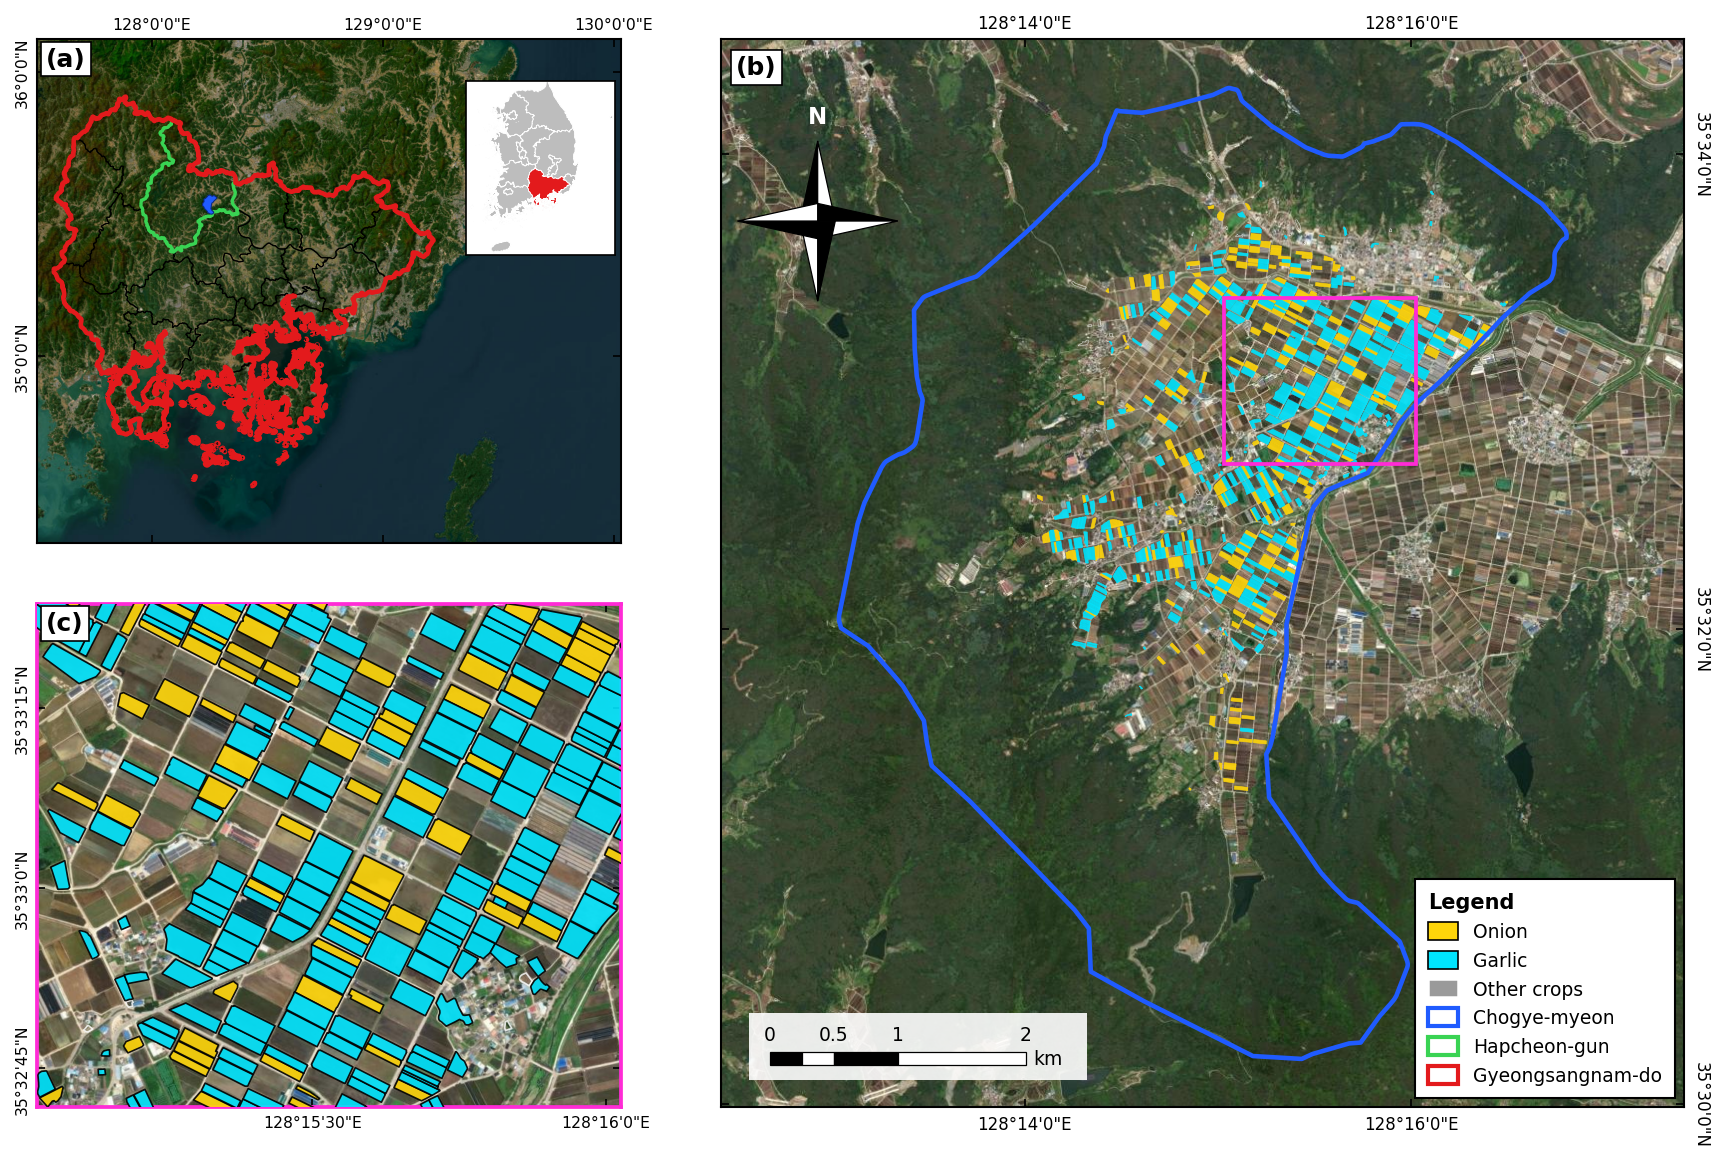

In [25]:
# ── Settings ──
YEAR = 2025
PLOT_CRS = "EPSG:3857"
CLASS_STYLE = {
    "양파": ("#ffd60a", "Onion"),
    "마늘": ("#00e5ff", "Garlic"),
}
OTHER_LABEL, OTHER_TEXT = "기타", "Other crops"
SHOW_OTHER = True

ADM_URL = ("https://raw.githubusercontent.com/vuski/admdongkor/master/"
           "ver20250701/HangJeongDong_ver20250701.geojson")
ADM_CACHE = os.path.join(OUTPUT_DIR, "korea_boundaries_cache.gpkg")
SIDO, SGG, EMD = "경상남도", "합천군", "초계면"
NAMES_EN = {"sido": "Gyeongsangnam-do", "sgg": "Hapcheon-gun", "emd": "Chogye-myeon"}

C_SIDO, C_SGG, C_EMD = "#e31a1c", "#39d353", "#1f5bff"   # red / green / blue
C_ZOOM = "#ff2bd6"
ZOOM_WIDTH_M = 1500         # ground width of panel (c) in metres
ZOOM_CENTER = None          # (lon, lat) to fix it; None = densest onion/garlic spot
IMAGERY = "Esri.WorldImagery"

to_ll = Transformer.from_crs(PLOT_CRS, "EPSG:4326", always_xy=True)
to_pc = Transformer.from_crs("EPSG:4326", PLOT_CRS, always_xy=True)


# ── Boundaries (downloaded once, cached on Drive) ──
def load_admin():
    if os.path.exists(ADM_CACHE):
        emd = gpd.read_file(ADM_CACHE, layer="emd")
        sido = gpd.read_file(ADM_CACHE, layer="sido")
    else:
        print("Downloading 읍면동 boundaries (~35 MB, once)...")
        allk = gpd.read_file(ADM_URL).to_crs("EPSG:5179")
        emd = allk[allk["sidonm"] == SIDO].copy()
        sido = allk.dissolve(by="sidonm").reset_index()[["sidonm", "geometry"]]
        sido["geometry"] = sido.geometry.simplify(200)
        emd.to_file(ADM_CACHE, layer="emd", driver="GPKG")
        sido.to_file(ADM_CACHE, layer="sido", driver="GPKG")
    emd = emd.to_crs(PLOT_CRS)
    emd["city"] = emd["sggnm"].str.split().str[0]          # 창원시 의창구 → 창원시
    sgg_all = emd.dissolve(by="city").reset_index()
    return dict(
        korea=sido.to_crs(PLOT_CRS),
        sido=emd.dissolve(),
        sgg_all=sgg_all,
        sgg=sgg_all[sgg_all["city"] == SGG],
        emd=emd[(emd["city"] == SGG) & (emd["adm_nm"].str.endswith(EMD))].dissolve(),
    )


def load_parcels(year):
    if "gdf_by_year" in globals() and year in gdf_by_year:
        gdf = gdf_by_year[year]
    else:
        cfg = YEAR_CONFIG[year]
        gdf = build_labeled_parcels(cfg["parcel_path"], ADDR_COL, LABEL_COL,
                                    TARGET_EUPMYEON, MIX_COL, MIX_RT_COL)
    return gdf[["label", "geometry"]].to_crs(PLOT_CRS)


# ── Helpers ──
def box_ratio(ax):
    bb = ax.get_position()
    fig = ax.figure
    return (bb.width * fig.get_figwidth()) / (bb.height * fig.get_figheight())


def fit_extent(ax, bounds, pad=0.05):
    """Set limits around bounds, expanded to the panel's shape (equal aspect, nothing cut)."""
    x0, y0, x1, y1 = bounds
    w, h = (x1 - x0) * (1 + 2 * pad), (y1 - y0) * (1 + 2 * pad)
    r = box_ratio(ax)
    w, h = (h * r, h) if w / h < r else (w, w / r)
    cx_, cy_ = (x0 + x1) / 2, (y0 + y1) / 2
    ax.set_xlim(cx_ - w / 2, cx_ + w / 2); ax.set_ylim(cy_ - h / 2, cy_ + h / 2)
    ax.set_aspect("equal")


def add_imagery(ax):
    try:
        src = cx.providers
        for part in IMAGERY.split("."):
            src = src[part]
        cx.add_basemap(ax, crs=PLOT_CRS, source=src, attribution=False, zorder=0)
    except Exception as e:
        ax.set_facecolor("#5b6b52")
        print("Imagery skipped:", e)


def dms(v, pos_char, neg_char):
    c = pos_char if v >= 0 else neg_char
    v = abs(v); d = int(v); m_f = (v - d) * 60; m = int(round(m_f, 6)); s = round((m_f - m) * 60)
    if s == 60: m, s = m + 1, 0
    if m == 60: d, m = d + 1, 0
    return f"{d}°{m}'{s}\"{c}"


def graticule(ax, x_sides=("bottom",), y_sides=("left",), n=3, fs=8):
    """Lat/lon tick labels (DMS) on a web-mercator axis."""
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    (lon0, lat0), (lon1, lat1) = to_ll.transform(x0, y0), to_ll.transform(x1, y1)
    steps = [15/3600, 30/3600, 1/60, 2/60, 5/60, 10/60, 15/60, 20/60, 30/60, 1, 2, 5]
    def pick(span):
        return next((s for s in steps if span / s <= n), steps[-1])
    sx, sy = pick(lon1 - lon0), pick(lat1 - lat0)
    lons = np.arange(np.ceil(lon0 / sx) * sx, lon1, sx)
    lats = np.arange(np.ceil(lat0 / sy) * sy, lat1, sy)
    ax.set_xticks([to_pc.transform(l, lat0)[0] for l in lons])
    ax.set_xticklabels([dms(l, "E", "W") for l in lons])
    ax.set_yticks([to_pc.transform(lon0, l)[1] for l in lats])
    ax.set_yticklabels([dms(l, "N", "S") for l in lats])
    ax.tick_params(direction="in", length=4, labelsize=fs, top=True, right=True,
                   labeltop="top" in x_sides, labelbottom="bottom" in x_sides,
                   labelleft="left" in y_sides, labelright="right" in y_sides)
    for t in ax.yaxis.get_major_ticks():
        t.label1.set_rotation(90); t.label1.set_va("center")
        t.label2.set_rotation(270); t.label2.set_va("center")
    for sp in ax.spines.values():
        sp.set_linewidth(1.0)


def panel_label(ax, txt):
    ax.text(0.015, 0.985, txt, transform=ax.transAxes, fontsize=12, fontweight="bold", va="top",
            ha="left", zorder=30, bbox=dict(fc="white", ec="black", lw=0.8, pad=2.5))


def compass(ax, x=0.13, y=0.84, L=0.075):
    """4-point compass star (black/white halves) + N, in axes fraction."""
    r = 1 / box_ratio(ax)
    c = np.array([x, y])
    for v in [(0, 1), (1, 0), (0, -1), (-1, 0)]:
        v = np.array(v, float); p = np.array([-v[1], v[0]])
        scale = np.array([r, 1.0])
        tip = c + v * L * scale; s1 = c + p * L * 0.22 * scale; s2 = c - p * L * 0.22 * scale
        ax.add_patch(Polygon([c, tip, s1], transform=ax.transAxes, fc="black", ec="black", lw=0.6, zorder=30))
        ax.add_patch(Polygon([c, tip, s2], transform=ax.transAxes, fc="white", ec="black", lw=0.6, zorder=30))
    ax.text(x, y + L + 0.012, "N", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=11, color="white", fontweight="bold", zorder=30)


def scalebar(ax, km_total, x=0.05, y=0.05, fs=9):
    """Segmented scale bar in true ground distance on web-mercator."""
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    lat = to_ll.transform((x0 + x1) / 2, (y0 + y1) / 2)[1]
    k = 1 / np.cos(np.radians(lat))                     # mercator stretch
    L = km_total * 1000 * k
    bx, by, h = x0 + (x1 - x0) * x, y0 + (y1 - y0) * y, (y1 - y0) * 0.012
    ax.add_patch(Rectangle((bx - L * 0.08, by - h * 1.2), L * 1.32, h * 5.2, fc="white",
                           ec="none", alpha=0.9, zorder=28))
    marks = [0, km_total / 4, km_total / 2, km_total]
    segs = [(0, km_total / 8), (km_total / 8, km_total / 4), (km_total / 4, km_total / 2), (km_total / 2, km_total)]
    for i, (a, b) in enumerate(segs):
        ax.add_patch(Rectangle((bx + a * 1000 * k, by), (b - a) * 1000 * k, h, zorder=29, lw=0.6,
                               fc="black" if i % 2 == 0 else "white", ec="black"))
    for m in marks:
        ax.text(bx + m * 1000 * k, by + h * 1.6, f"{m:g}", ha="center", va="bottom", fontsize=fs, zorder=29)
    ax.text(bx + L + L * 0.03, by + h * 0.5, "km", ha="left", va="center", fontsize=fs, zorder=29)


def nice_km(span_km):
    opts = [0.2, 0.4, 0.8, 1, 2, 4, 8, 16, 20, 40, 80]
    return max([v for v in opts if v <= span_km * 0.3] or [opts[0]])


def draw_parcels(ax, gdf, overview):
    if SHOW_OTHER:
        gdf[gdf["label"] == OTHER_LABEL].plot(ax=ax, facecolor="none", edgecolor="white",
                                              linewidth=0.25 if overview else 0.8, alpha=0.8, zorder=5)
    for lab, (col, _) in CLASS_STYLE.items():
        sub = gdf[gdf["label"] == lab]
        if len(sub):
            sub.plot(ax=ax, facecolor=col, edgecolor="black" if not overview else col,
                     linewidth=0.8 if not overview else 0.3, alpha=0.9, zorder=6)


def densest_center(gdf, size):
    pts = gdf.geometry.centroid
    xs, ys, ar = pts.x.values, pts.y.values, gdf.geometry.area.values
    best, score = (xs.mean(), ys.mean()), -1
    for x, y in zip(xs, ys):
        m = (np.abs(xs - x) <= size / 2) & (np.abs(ys - y) <= size / 2)
        if ar[m].sum() > score:
            best, score = (x, y), ar[m].sum()
    return best


# ── Data ──
adm = load_admin()
parcels = load_parcels(YEAR)
lat_c = to_ll.transform(*adm["emd"].geometry.iloc[0].centroid.coords[0])[1]
k_merc = 1 / np.cos(np.radians(lat_c))

# ── Layout: (a) top-left, (c) bottom-left, (b) right spanning both ──
fig = plt.figure(figsize=(12, 8), dpi=150)
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.65], left=0.05, right=0.965, top=0.95,
                      bottom=0.06, wspace=0.13, hspace=0.12)
ax_a, ax_c, ax_b = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[:, 1])

# zoom window with the same shape as panel (c)
zw = ZOOM_WIDTH_M * k_merc
zh = zw / box_ratio(ax_c)
if ZOOM_CENTER:
    zc = to_pc.transform(*ZOOM_CENTER)
else:
    focus = parcels[parcels["label"].isin(CLASS_STYLE)]
    zc = densest_center(focus if len(focus) else parcels, zw)
zoom_box = box(zc[0] - zw / 2, zc[1] - zh / 2, zc[0] + zw / 2, zc[1] + zh / 2)
print("Zoom centre (lon, lat):", tuple(round(v, 5) for v in to_ll.transform(*zc)))

# ── (a) locator ──
sx0, sy0, sx1, sy1 = adm["sido"].total_bounds
fit_extent(ax_a, (sx0, sy0, sx1 + (sx1 - sx0) * 0.45, sy1), pad=0.03)   # room on the right for the inset
add_imagery(ax_a)
adm["sgg_all"].boundary.plot(ax=ax_a, color="black", linewidth=0.5, zorder=3)
adm["sgg"].boundary.plot(ax=ax_a, color=C_SGG, linewidth=1.6, zorder=4)
adm["emd"].plot(ax=ax_a, color=C_EMD, edgecolor="#0b2a80", linewidth=0.5, zorder=5)
adm["sido"].boundary.plot(ax=ax_a, color=C_SIDO, linewidth=2.2, zorder=6)
graticule(ax_a, x_sides=("top",), y_sides=("left",), n=3, fs=7.5)
panel_label(ax_a, "(a)")

ins = ax_a.inset_axes([0.735, 0.50, 0.255, 0.49])
kor = adm["korea"]
kor.plot(ax=ins, color="#bdbdbd", edgecolor="white", linewidth=0.4)
kor[kor["sidonm"] == SIDO].plot(ax=ins, color=C_SIDO, edgecolor="white", linewidth=0.4)
kx0, ky0, kx1, ky1 = kor.total_bounds
ins.set_xlim(kx0 + (kx1 - kx0) * 0.08, kx1 - (kx1 - kx0) * 0.12); ins.set_ylim(ky0, ky1)
ins.set_aspect("equal"); ins.set_xticks([]); ins.set_yticks([]); ins.set_facecolor("white")
for sp in ins.spines.values():
    sp.set_linewidth(0.8)

# ── (b) study area ──
fit_extent(ax_b, adm["emd"].total_bounds, pad=0.05)
add_imagery(ax_b)
draw_parcels(ax_b, parcels, overview=True)
adm["emd"].boundary.plot(ax=ax_b, color=C_EMD, linewidth=2.2, zorder=8)
zx0, zy0, zx1, zy1 = zoom_box.bounds
ax_b.add_patch(Rectangle((zx0, zy0), zx1 - zx0, zy1 - zy0, fill=False, ec=C_ZOOM, lw=1.8, zorder=9))
graticule(ax_b, x_sides=("top", "bottom"), y_sides=("right",), n=3, fs=8)
panel_label(ax_b, "(b)")
compass(ax_b, x=0.10, y=0.83)
bx0, bx1 = ax_b.get_xlim()
scalebar(ax_b, nice_km((bx1 - bx0) / k_merc / 1000), x=0.05, y=0.04)

handles = [Patch(fc=c, ec="black", lw=0.8, label=t) for c, t in CLASS_STYLE.values()]
if SHOW_OTHER:
    handles.append(Patch(fc="#9a9a9a", ec="white", lw=1.2, label=OTHER_TEXT))
handles += [Patch(fc="none", ec=C_EMD, lw=2.0, label=NAMES_EN["emd"]),
            Patch(fc="none", ec=C_SGG, lw=2.0, label=NAMES_EN["sgg"]),
            Patch(fc="none", ec=C_SIDO, lw=2.0, label=NAMES_EN["sido"])]
leg = ax_b.legend(handles=handles, title="Legend", loc="lower right", fontsize=9, title_fontsize=10,
                  frameon=True, fancybox=False, framealpha=1, edgecolor="black",
                  handlelength=1.6, handleheight=1.1, borderpad=0.7)
leg.get_title().set_fontweight("bold"); leg.get_title().set_ha("left")
leg._legend_box.align = "left"
leg.set_zorder(30)

# ── (c) zoom ──
ax_c.set_xlim(zx0, zx1); ax_c.set_ylim(zy0, zy1); ax_c.set_aspect("equal")
add_imagery(ax_c)
draw_parcels(ax_c, parcels.clip(zoom_box.buffer(zw * 0.02)), overview=False)
ax_c.set_xlim(zx0, zx1); ax_c.set_ylim(zy0, zy1)
graticule(ax_c, x_sides=("bottom",), y_sides=("left",), n=3, fs=7.5)
for sp in ax_c.spines.values():
    sp.set_edgecolor(C_ZOOM); sp.set_linewidth(1.8)
panel_label(ax_c, "(c)")

fig.savefig(os.path.join(OUTPUT_DIR, f"study_area_3panel_{YEAR}.png"), dpi=300, bbox_inches="tight")
plt.show()